In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data")

print("Path to dataset files:", path)

c:\Users\ADISH\anaconda3\envs\tf_gpu\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
c:\Users\ADISH\anaconda3\envs\tf_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.78G/1.78G [01:53<00:00, 16.8MB/s]

Extracting files...


Path to dataset files: C:\Users\ADISH\.cache\kagglehub\datasets\elemento\nyc-yellow-taxi-trip-data\versions\2


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [5]:
df = pd.read_csv("yellow_tripdata_2015-01.csv")

print(df.shape)


(12748986, 19)


In [6]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30


In [7]:
numerical_cols = [
    "passenger_count", "trip_distance", "fare_amount",
    "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount"
]

categorical_cols = [
    "VendorID", "RateCodeID", "store_and_fwd_flag", "payment_type"
]

datetime_cols = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime"
]

geo_cols = [
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude"
]

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)
print("Datetime:", datetime_cols)
print("Geographical:", geo_cols)


Numerical: ['passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount']
Categorical: ['VendorID', 'RateCodeID', 'store_and_fwd_flag', 'payment_type']
Datetime: ['tpep_pickup_datetime', 'tpep_dropoff_datetime']
Geographical: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']


In [8]:
missing_values = df[numerical_cols].isnull().sum()

print("Missing Values:\n", missing_values)


Missing Values:
 passenger_count          0
trip_distance            0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    3
total_amount             0
dtype: int64


In [9]:
df[numerical_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
passenger_count,12748986.0,1.681491,1.337924,0.00,1.00,1.00,2.00,9.00
trip_distance,12748986.0,13.459130,9844.094218,0.00,1.00,1.68,3.00,15420004.50
fare_amount,12748986.0,11.905659,10.302537,-450.00,6.50,9.00,13.50,4008.00
extra,12748986.0,0.308279,0.591664,-79.00,0.00,0.00,0.50,999.99
mta_tax,12748986.0,0.497799,0.035342,-0.50,0.50,0.50,0.50,0.50
tip_amount,12748986.0,1.853814,1106.432314,-92.42,0.00,1.00,2.06,3950588.80
tolls_amount,12748986.0,0.243498,1.527171,-26.00,0.00,0.00,0.00,1450.09
improvement_surcharge,12748983.0,0.283143,0.069086,0.00,0.30,0.30,0.30,0.30
total_amount,12748986.0,15.108295,1106.503247,-450.30,8.16,11.16,16.30,3950611.60


In [10]:
# for col in numerical_cols:
#     plt.figure()
#     sns.histplot(df[col], bins=50, kde=True)
#     plt.title(f"Distribution of {col}")
#     plt.show()


In [11]:

# for col in numerical_cols:
#     plt.figure()
#     sns.boxplot(x=df[col])
#     plt.title(f"Boxplot of {col}")
#     plt.show()


In [12]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()


In [13]:
outlier_summary = {}

for col in numerical_cols:
    outlier_summary[col] = detect_outliers_iqr(df[col])

pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier Count"])


,Outlier Count
passenger_count,1405471
trip_distance,1259087
fare_amount,1048995
extra,717
mta_tax,52224
tip_amount,631614
tolls_amount,540455
improvement_surcharge,716362
total_amount,1090560


# STEP 8: SKEWNESS ANALYSIS

In [14]:
skewness_df = pd.DataFrame({
    "Feature": numerical_cols,
    "Skewness": [skew(df[col].dropna()) for col in numerical_cols]
})

skewness_df


,Feature,Skewness
0,passenger_count,2.085022
1,trip_distance,1148.770864
2,fare_amount,12.615395
3,extra,775.017668
4,mta_tax,-17.486137
5,tip_amount,3570.546772
6,tolls_amount,212.227821
7,improvement_surcharge,-3.854397
8,total_amount,3569.886038


In [15]:
def skew_type(value):
    if value > 1:
        return "Highly Right Skewed"
    elif value > 0.5:
        return "Moderately Right Skewed"
    elif value < -1:
        return "Highly Left Skewed"
    elif value < -0.5:
        return "Moderately Left Skewed"
    else:
        return "Approximately Symmetric"

skewness_df["Distribution Type"] = skewness_df["Skewness"].apply(skew_type)
skewness_df


,Feature,Skewness,Distribution Type
0,passenger_count,2.085022,Highly Right Skewed
1,trip_distance,1148.770864,Highly Right Skewed
2,fare_amount,12.615395,Highly Right Skewed
3,extra,775.017668,Highly Right Skewed
4,mta_tax,-17.486137,Highly Left Skewed
5,tip_amount,3570.546772,Highly Right Skewed
6,tolls_amount,212.227821,Highly Right Skewed
7,improvement_surcharge,-3.854397,Highly Left Skewed
8,total_amount,3569.886038,Highly Right Skewed


# STEP 9: CATEGORICAL UNIVARIATE ANALYSIS

In [16]:
# for col in categorical_cols:
#     plt.figure()
#     sns.countplot(x=df[col])
#     plt.title(f"Count Plot of {col}")
#     plt.xticks(rotation=45)
#     plt.show()

#     print(df[col].value_counts())
#     print("-" * 40)


# STEP 10: FEATURE-WISE CONCLUSIONS (REPORT READY)

In [17]:
for col in numerical_cols:
    print(f"\nFeature: {col}")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Skewness: {skew(df[col]):.2f}")
    print(f"Outliers (IQR): {detect_outliers_iqr(df[col])}")



Feature: passenger_count
Mean: 1.68
Median: 1.00
Skewness: 2.09
Outliers (IQR): 1405471

Feature: trip_distance
Mean: 13.46
Median: 1.68
Skewness: 1148.77
Outliers (IQR): 1259087

Feature: fare_amount
Mean: 11.91
Median: 9.00
Skewness: 12.62
Outliers (IQR): 1048995

Feature: extra
Mean: 0.31
Median: 0.00
Skewness: 775.02
Outliers (IQR): 717

Feature: mta_tax
Mean: 0.50
Median: 0.50
Skewness: -17.49
Outliers (IQR): 52224

Feature: tip_amount
Mean: 1.85
Median: 1.00
Skewness: 3570.55
Outliers (IQR): 631614

Feature: tolls_amount
Mean: 0.24
Median: 0.00
Skewness: 212.23
Outliers (IQR): 540455

Feature: improvement_surcharge
Mean: 0.28
Median: 0.30
Skewness: nan
Outliers (IQR): 716362

Feature: total_amount
Mean: 15.11
Median: 11.16
Skewness: 3569.89
Outliers (IQR): 1090560


OUTLIER TREATMENT (CAPPING & TRANSFORMATION)

In [18]:
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)
    return df


In [19]:
skewed_cols = [
    "trip_distance", "fare_amount", "tip_amount",
    "tolls_amount", "total_amount"
]

for col in skewed_cols:
    df = cap_outliers_iqr(df, col)


In [20]:
for col in skewed_cols:
    df[col + "_log"] = np.log1p(df[col])


c:\Users\ADISH\anaconda3\envs\tf_gpu\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ADISH\anaconda3\envs\tf_gpu\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ADISH\anaconda3\envs\tf_gpu\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ADISH\anaconda3\envs\tf_gpu\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\ADISH\anaconda3\envs\tf_gpu\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


BIVARIATE ANALYSIS

In [21]:
# sample_df = df.sample(100000, random_state=42)

# plt.figure(figsize=(8,5))
# sns.scatterplot(
#     x=sample_df["trip_distance"],
#     y=sample_df["fare_amount"],
#     alpha=0.3
# )
# plt.title("Fare Amount vs Trip Distance")
# plt.xlabel("Trip Distance")
# plt.ylabel("Fare Amount")
# plt.show()


In [22]:
df[["trip_distance", "fare_amount"]].corr()


,trip_distance,fare_amount
trip_distance,1.000000,0.946429
fare_amount,0.946429,1.000000


In [23]:
# plt.figure(figsize=(8,5))
# sns.boxplot(
#     x="payment_type",
#     y="tip_amount",
#     data=df
# )
# plt.title("Tip Amount vs Payment Type")
# plt.show()


In [24]:
# sns.pairplot(
#     df[[col + "_log" for col in skewed_cols]],
#     corner=True
# )
# plt.show()


FEATURE ENGINEERING

In [25]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.weekday


In [26]:
df["has_tip"] = (df["tip_amount"] > 0).astype(int)
df["has_toll"] = (df["tolls_amount"] > 0).astype(int)
df["has_extra"] = (df["extra"] > 0).astype(int)


In [27]:
# Convert to category
df["payment_type"] = df["payment_type"].astype("category")
df["RateCodeID"] = df["RateCodeID"].astype("category")

# Encode safely
df["payment_type_enc"] = df["payment_type"].cat.codes
df["RateCodeID_enc"] = df["RateCodeID"].cat.codes

# Drop original columns
df.drop(columns=["payment_type", "RateCodeID"], inplace=True)


In [28]:
drop_cols = [
    "improvement_surcharge",
    "store_and_fwd_flag",
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude"
]

df.drop(columns=drop_cols, inplace=True)


MODELING

🎯 PROBLEM STATEMENT

Predict fare_amount using trip characteristics

In [29]:
#5.1 SELECT FEATURES & TARGET
target = "fare_amount_log"

features = [
    "trip_distance_log",
    "passenger_count",
    "pickup_hour",
    "pickup_weekday",
    "has_toll",
    "has_extra"
]

X = df[features]
y = df[target]


In [30]:
# 5.2 TRAIN–TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [32]:
y.isna().sum()


4055

In [33]:
df["fare_amount"].describe()

df[df["fare_amount"] <= 0].shape


(7666, 24)

In [34]:
df = df[df["fare_amount"] > 0]
df["fare_amount_log"] = np.log1p(df["fare_amount"])
df["fare_amount_log"].isna().sum()


0

In [35]:
X.isna().sum()
X = X.fillna(0)


In [36]:
X = df[features]
y = df["fare_amount_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [37]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 0.10752608838100125
RMSE: 0.1652367097593239


In [38]:
X_test

,trip_distance_log,passenger_count,pickup_hour,pickup_weekday,has_toll,has_extra
10495578,0.741937,1,15,2,0,0
4600868,1.386294,1,20,3,0,1
10331900,1.568616,2,1,4,0,1
11235333,0.530628,1,7,2,0,0
9216191,1.211941,3,3,0,0,1
...,...,...,...,...,...,...
2799175,1.163151,2,8,4,0,0
1105902,1.223775,2,17,5,0,0
4719456,0.832909,1,9,4,0,0
8133015,0.693147,3,21,5,0,1


In [39]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))

from sklearn.metrics import mean_absolute_error, mean_squared_error
print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))


Baseline MAE: 0.38986020016868367
Baseline RMSE: 0.4731690872836625


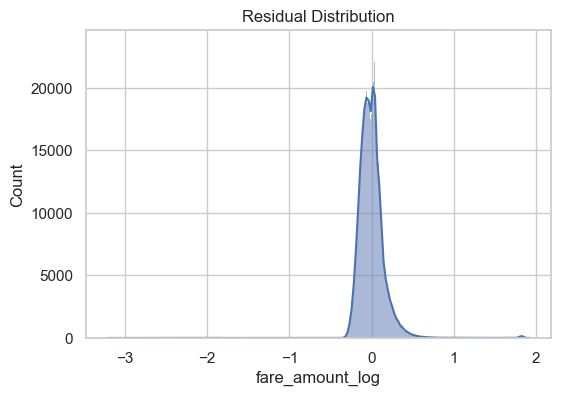

In [40]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()


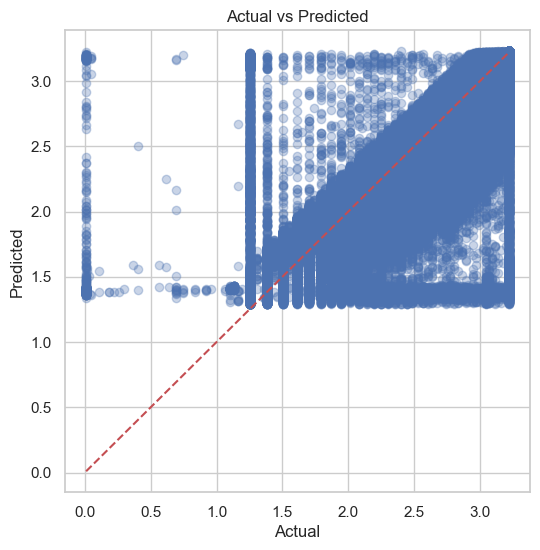

In [41]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


In [42]:
df_test = X_test.copy()
df_test["actual"] = y_test
df_test["predicted"] = y_pred
df_test["abs_error"] = np.abs(df_test["actual"] - df_test["predicted"])

df_test.groupby("passenger_count")["abs_error"].mean()



passenger_count
0    0.162900
1    0.108835
2    0.104130
3    0.104562
4    0.104770
5    0.103889
6    0.104891
7    0.122849
8    0.341755
9    0.980404
Name: abs_error, dtype: float64